Data
├ Water Data
│ ├ data_2012.csv
│   ├ ymdhm : 년월일시분
│   ├ swl : 팔당댐 현재수위 (단위: El.m)
│   ├ inf : 팔당댐 유입량 (단위: m^3/s)
│   ├ sfw : 팔당댐 저수량 (단위: 만m^3)
│   ├ ecpc : 팔당댐 공용량 (단위: 백만m^3)
│   ├ tototf : 총 방류량 (단위: m^3/s)
│   ├ tide_level : 강화대교 조위 (단위: cm)
│   ├ wl_1018662 : 청담대교 수위 (단위: cm)
│   ├ fw_1018662 : 청담대교 유량 (단위: m^3/s)
│   ├ wl_1018680 : 잠수교 수위 (단위: cm)
│   ├ fw_1018680 : 잠수교 유량 (단위: m^3/s)
│   ├ wl_1018683 : 한강대교 수위 (단위: cm)
│   ├ fw_1018683 : 한강대교 유량 (단위: m^3/s)
│   ├ wl_1019630 : 행주대교 수위 (단위: cm)
│   └ fw_1019630 : 행주대교 유량 (단위: m^3/s)
│ ├ data_2013.csv
…
└ └ data_2022.csv
└ RainFall Data
│ ├ rf_2012.csv
│   ├ YMDHM : 년월일시분
│   ├ rf_10184100 : 대곡교 강수량
│   ├ rf_10184110 : 진관교 강수량
│   └ rf_10184140 : 송정동 강수량
│ ├ rf_2013.csv
…
└ └ rf_2022.csv

In [5]:
_input_path = '../data'
# _input_path = '/data'

import numpy as np
import pandas as pd
import os

def load_data(data_type):
    dataset_path = f'{_input_path}/{data_type}_data'
    dfs = []
    for file_name in sorted(os.listdir(f'{dataset_path}/')):
        if not file_name.endswith('.csv'):
            continue
        df = pd.read_csv(f'{dataset_path}/{file_name}', parse_dates=['ymdhm'])
        dfs.append( df )
    return pd.concat(dfs, axis=0, ignore_index=True)

In [17]:
df_rf = load_data('rf')
df_water = load_data('water')
df = pd.merge(df_water, df_rf, on='ymdhm')

mask_train = (df['ymdhm'] < pd.Timestamp(2022, 6, 1))
mask_test = (df['ymdhm'] >= pd.Timestamp(2022, 6, 1))

In [18]:
df.head()

,ymdhm,swl,inf,sfw,ecpc,tototf,tide_level,wl_1018662,fw_1018662,wl_1018680,fw_1018680,wl_1018683,fw_1018683,wl_1019630,fw_1019630,rf_10184100,rf_10184110,rf_10184140
0,2012-05-01 00:00:00,24.800,555.0,219.07,24.93,555.0,445.0,310.7,469.05,300.2,0.0,290.0,729.80,275.3,540.18,0.0,0.0,0.0
1,2012-05-01 00:10:00,24.794,464.6,218.86,25.15,562.9,449.0,314.7,498.00,300.2,0.0,290.0,731.48,275.3,540.18,0.0,0.0,0.0
2,2012-05-01 00:20:00,24.789,478.1,218.69,25.31,576.4,451.0,313.7,490.68,301.2,0.0,290.0,726.42,275.3,540.18,0.0,0.0,0.0
3,2012-05-01 00:30:00,24.789,464.8,218.69,25.31,563.1,452.0,311.7,476.21,301.2,0.0,290.0,726.42,276.3,552.17,0.0,0.0,0.0
4,2012-05-01 00:40:00,24.789,478.1,218.69,25.31,576.4,450.0,311.7,476.21,301.2,0.0,291.0,707.17,277.3,564.29,0.0,0.0,0.0


In [77]:
time = df['ymdhm']
df['swl'] = df['swl'].where(df['swl'] > 5, np.nan)
df['inf'] = df['inf'].where(df['inf'] < 22000, np.nan)
df['inf'] = df['inf'].where((time < pd.Timestamp(2016, 1, 1)) | (time > pd.Timestamp(2017, 1, 1)) | (df['inf'] < 15000), np.nan)
df['inf'] = df['inf'].where((time < pd.Timestamp(2018, 10, 16)) | (time > pd.Timestamp(2018, 10, 17)) | df['inf'] < 3000, np.nan)
df['inf'] = df['inf'].where((time < pd.Timestamp(2018, 7, 5)) | (time > pd.Timestamp(2018, 7, 6)) | df['inf'] > 0, np.nan)

df['tototf'] = df['tototf'].where(df['tototf'] < 20000, np.nan)
df['tototf'] = df['tototf'].where((time < pd.Timestamp(2016, 1, 1)) | (time > pd.Timestamp(2017, 1, 1)) | (df['tototf'] < 15000), np.nan)


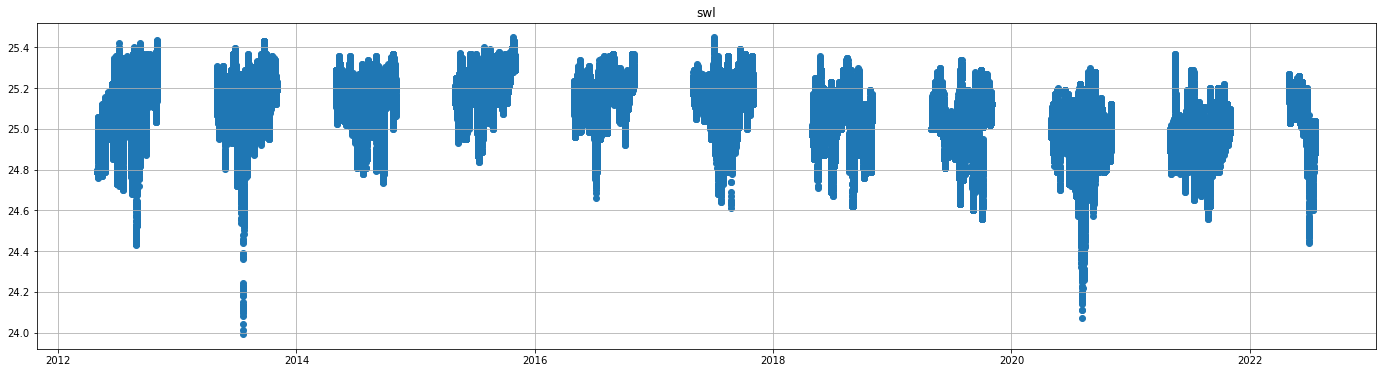

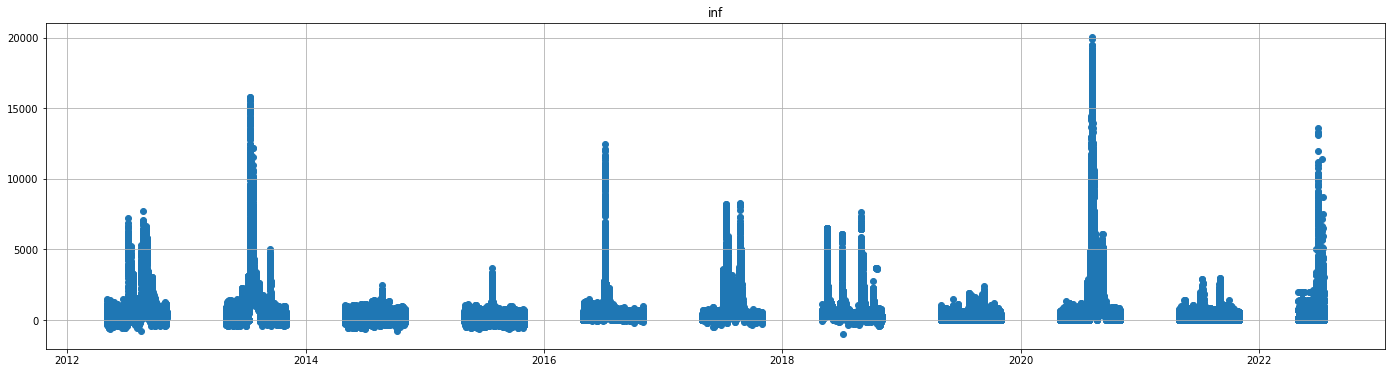

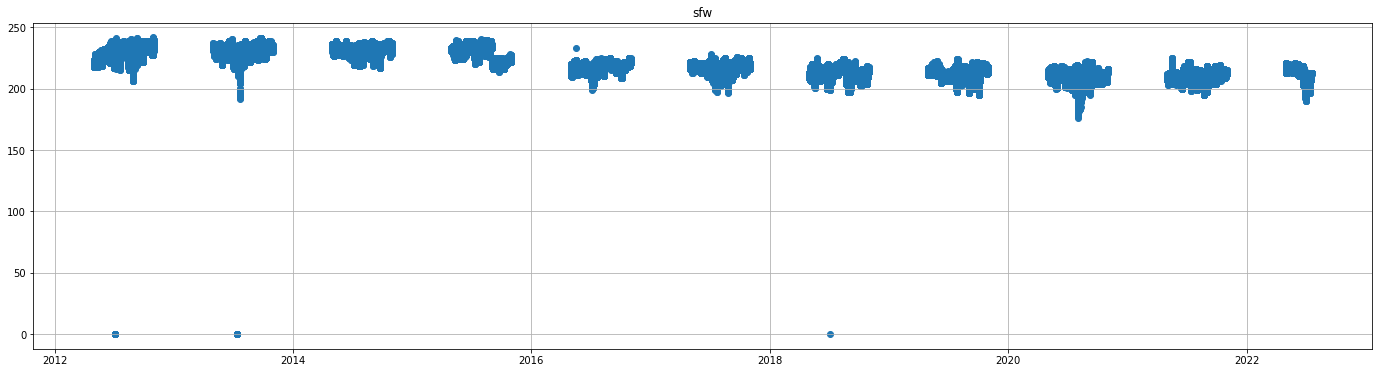

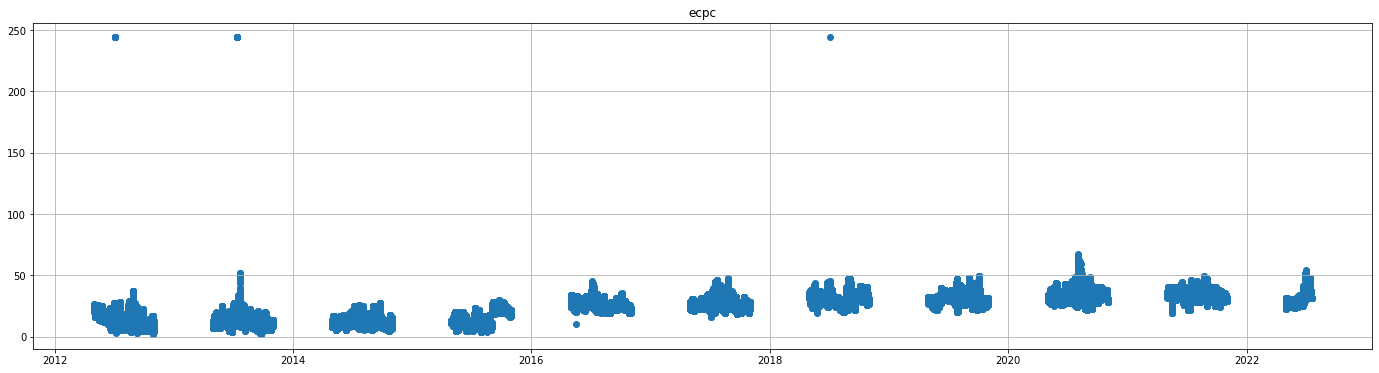

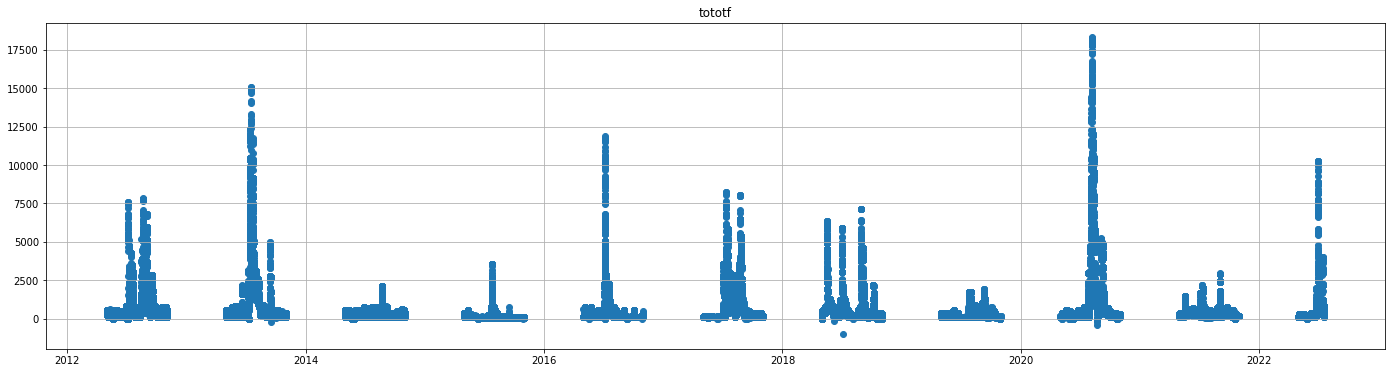

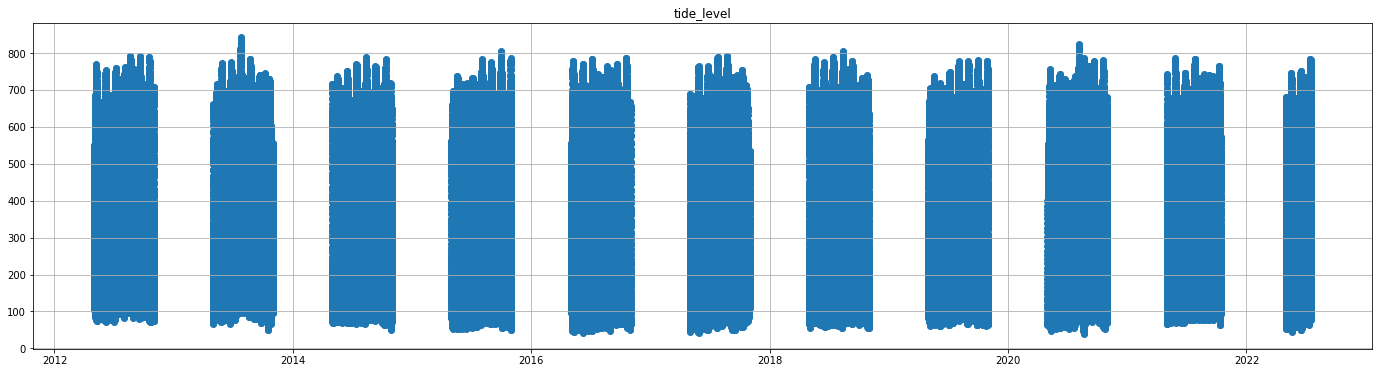

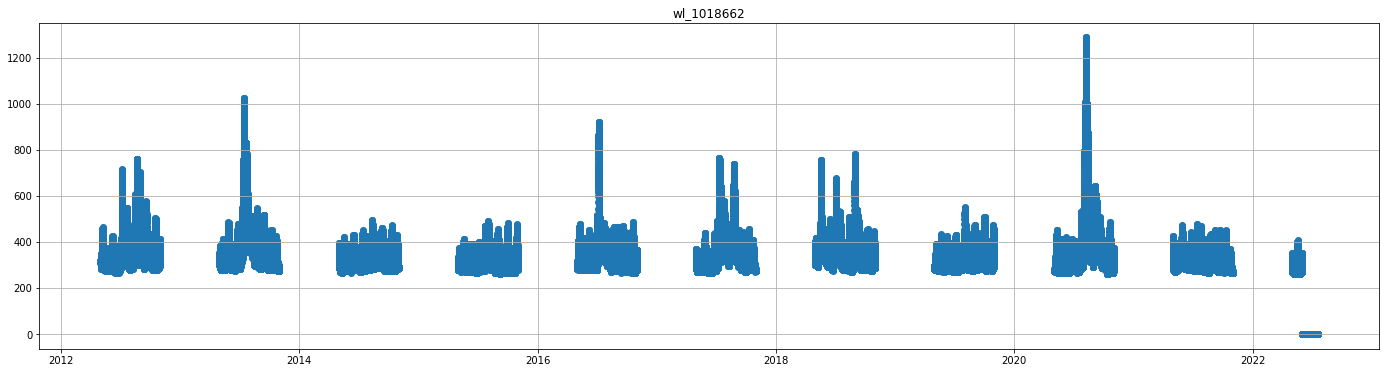

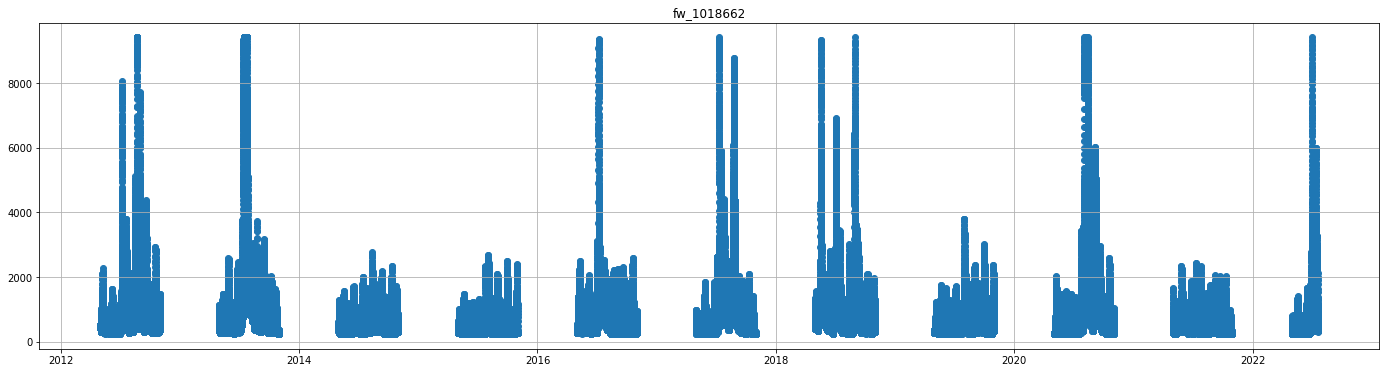

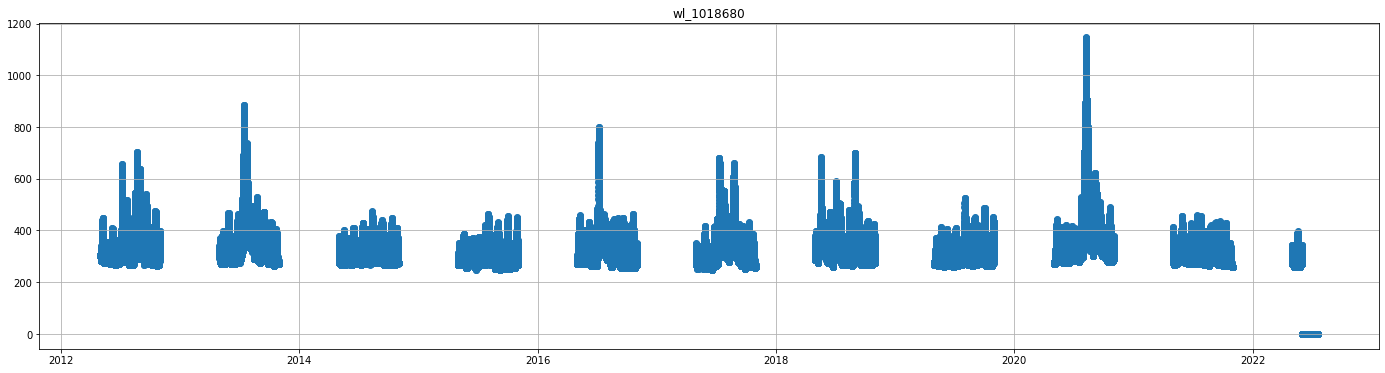

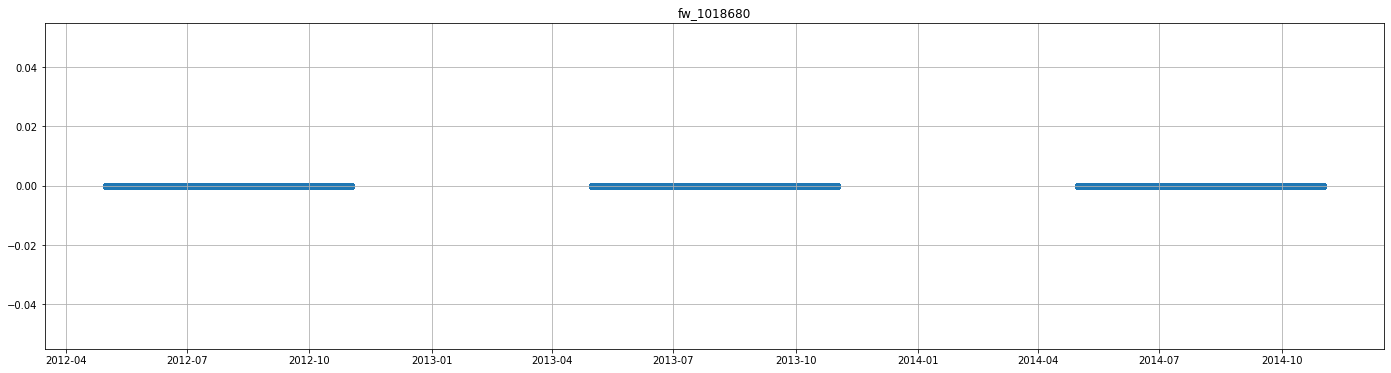

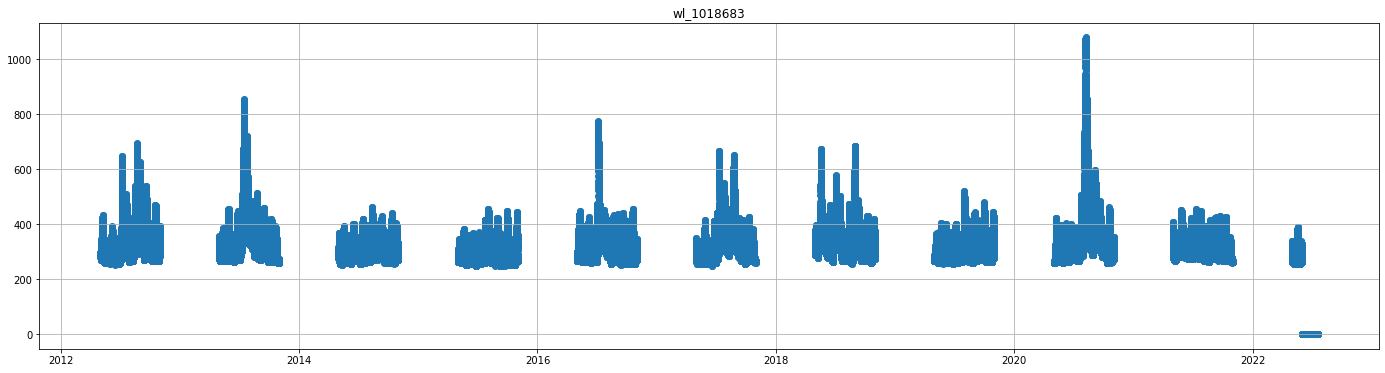

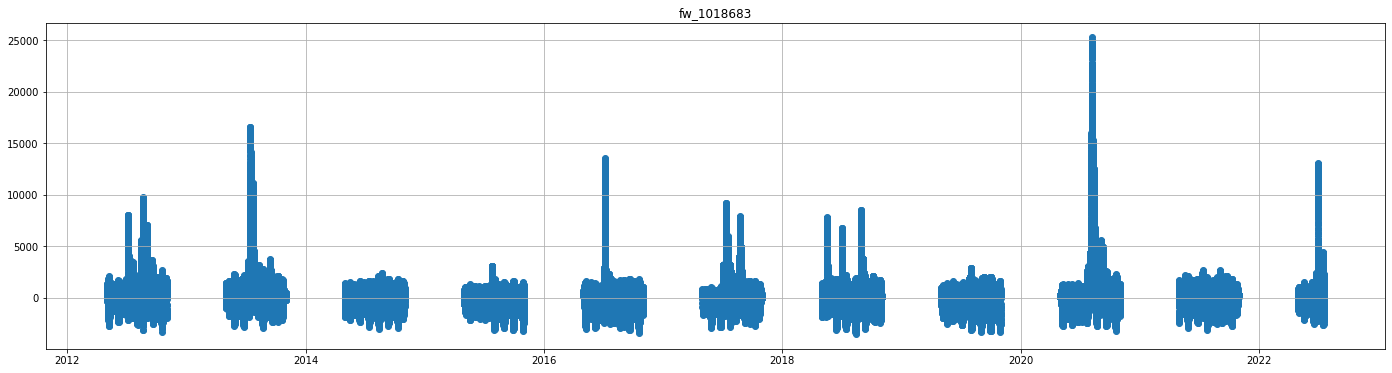

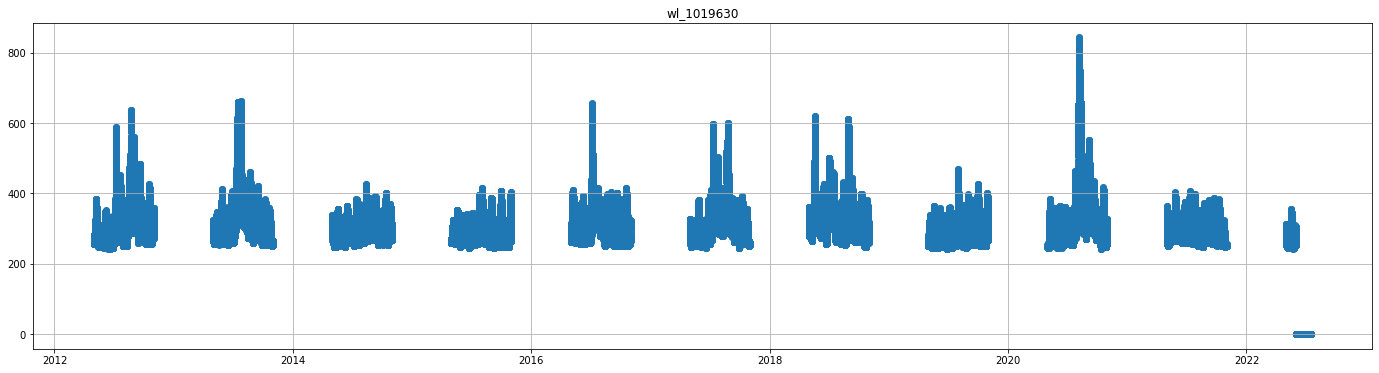

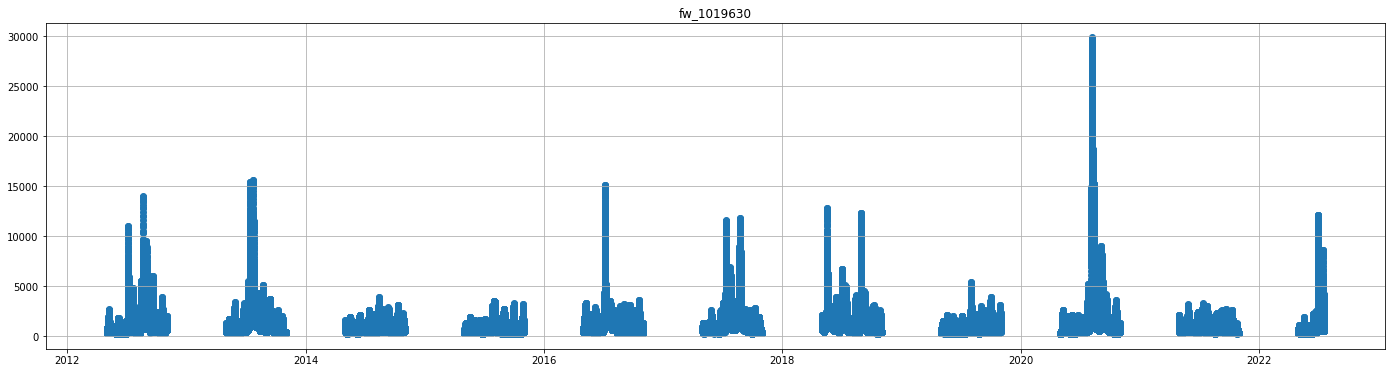

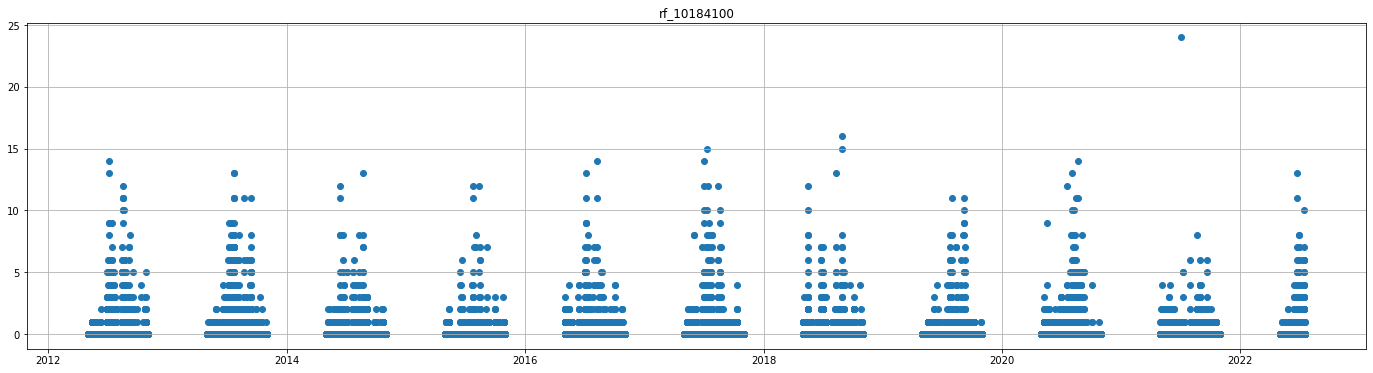

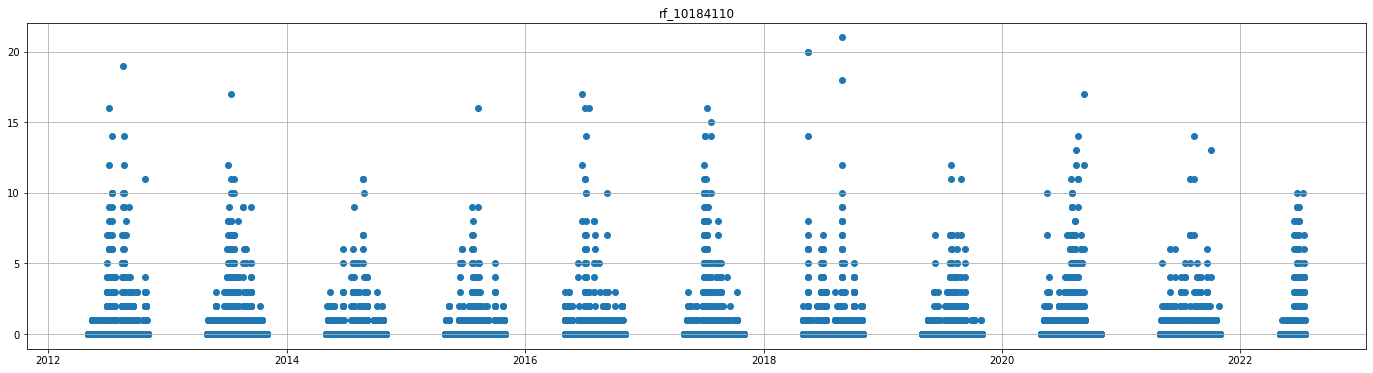

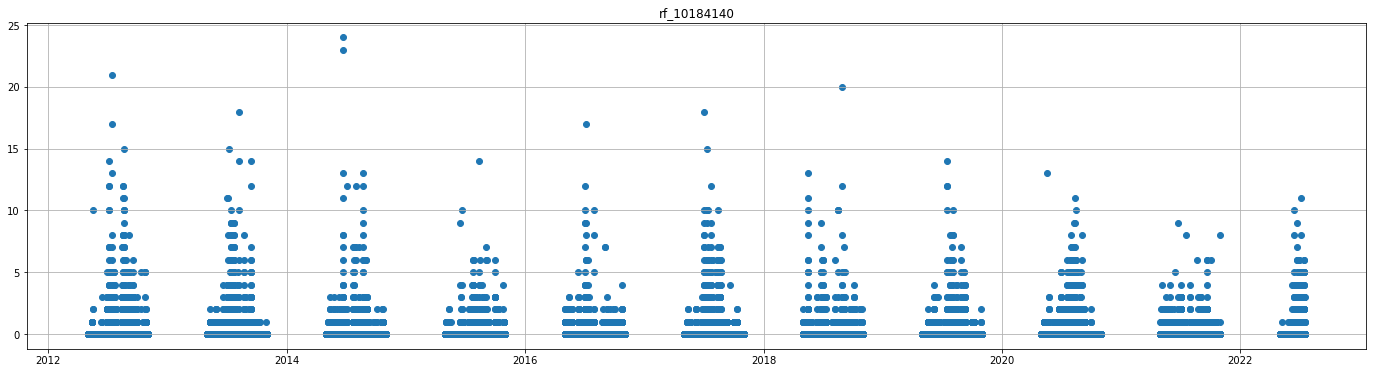

In [78]:
import matplotlib.pyplot as plt

for col_name in df.columns[1:]:
    plt.figure(figsize=(24, 6))
    plt.scatter(df['ymdhm'], df[col_name])
    plt.title(col_name)
    plt.grid(); plt.show(); plt.close();

In [95]:
def features_for_learning(df):
    usable_features = [
        'swl', 'inf', 'sfw', 'tototf', 'tide_level', 'fw_1018683', 
        'rf_10184100', 'rf_10184110', 'rf_10184140'
    ]
    result = dict()
#     result['ymdhm'] = df['ymdhm']
    for name in usable_features:
        for i in range(1, 6+1):
            result[f'{name}_s{i}'] = df[name].shift(i)
    return pd.DataFrame(result)

def labels_for_learning(df):
    return df[['wl_1018662', 'wl_1018680', 'wl_1018683', 'wl_1019630']]

In [96]:
df_features = features_for_learning(df)
df_labels = labels_for_learning(df)

In [91]:
mask_v_train = (df['ymdhm'] < pd.Timestamp(2021, 6, 1))
mask_v_test = (df['ymdhm'] >= pd.Timestamp(2021, 6, 1)) & (df['ymdhm'] < pd.Timestamp(2022, 1, 1))

In [97]:
X_train, Y_train = df_features[mask_v_train], df_labels[mask_v_train]
X_test, Y_test = df_features[mask_v_test], df_labels[mask_v_test]


In [102]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

mask_notna = (X_train.notna().all(axis=1) & Y_train.notna().all(axis=1))

model = Pipeline([
    ('std_scaler', StandardScaler()), 
    ('ridge', Ridge())
])
model.fit(X_train[mask_notna], Y_train[mask_notna].iloc[:, 0])

Pipeline(steps=[('std_scaler', StandardScaler()), ('ridge', Ridge())])

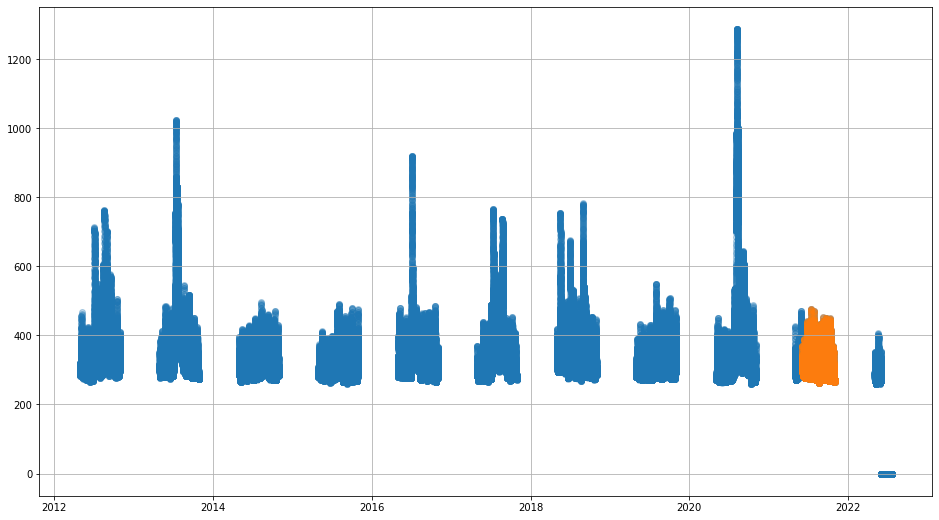

In [115]:
y_pred = pd.Series(np.full_like(Y_test.iloc[:, 0], np.nan), index=Y_test.index)
mask_notna = X_test.notna().all(axis=1)
y_pred[mask_notna] = model.predict(X_test[mask_notna])

plt.figure(figsize=(16, 9))
plt.scatter(time, df['wl_1018662'], alpha=0.3)
plt.scatter(time[mask_v_test], Y_test.iloc[:, 0], alpha=0.3)
plt.grid();
plt.show(); plt.close();